# Chapter 5 — Patterns in Nature and Algorithms

> **Prerequisites:** ch001–ch004
>
> **You will learn:**
> - How the same mathematical patterns appear in both natural phenomena and algorithmic processes
> - The Fibonacci sequence as a case study connecting nature, recursion, and the golden ratio
> - Power laws: what they are, where they appear, and how to detect them
> - Why pattern recognition is a core mathematical skill — and how to do it rigorously
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

One of the most striking facts in mathematics is that the same patterns appear across completely unrelated domains. The Fibonacci sequence emerges in rabbit populations, sunflower seed arrangements, and the recursion depth of naive algorithms. Power laws appear in city sizes, word frequencies, file sizes, and network degree distributions.

This is not coincidence. These patterns arise because they are solutions to *structural constraints* that many different systems share. When you recognize a pattern in a new context, you inherit everything known about it from all prior contexts.

**This chapter's goal:** Learn to see patterns structurally — not as superficial resemblances but as evidence of shared mathematical constraints.

## 2. Intuition & Mental Models

**Physical analogy:** Why do river deltas, lung bronchi, and tree branches all branch in similar ways? Because they all solve the same optimization problem: distribute flow through a volume as efficiently as possible. The branching pattern is the mathematical solution. The biology/geology is just the medium.

**Computational analogy:** Merge sort's runtime satisfies T(n) = 2T(n/2) + O(n). The binary tree structure of divide-and-conquer algorithms produces the same branching pattern as physical distribution networks. The recurrence relation is the shared mathematical constraint.

Recall from ch003 *(Abstraction and Modeling)*: we strip domain details to find shared structure. Patterns in nature are what shared structure *looks like* before the stripping.

## 3. Visualization

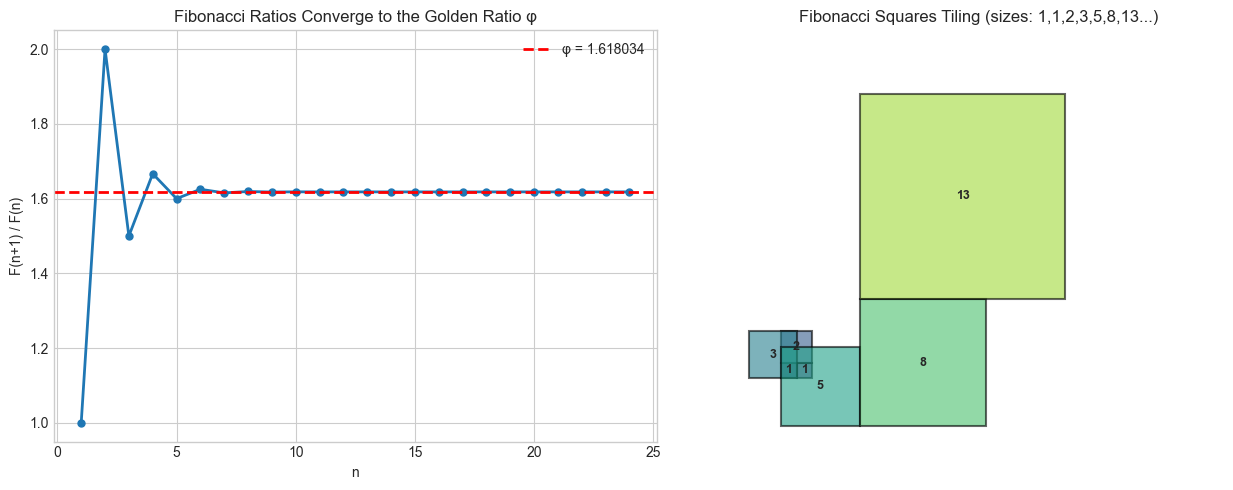

Golden ratio φ = 1.6180339887
F(25)/F(24) = 1.6180339890
Error: 2.08e-10


In [1]:
# --- Visualization: Fibonacci spiral and golden ratio convergence ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-v0_8-whitegrid')

def fibonacci(n):
    """Return first n Fibonacci numbers."""
    fibs = [1, 1]
    while len(fibs) < n:
        fibs.append(fibs[-1] + fibs[-2])
    return fibs[:n]

N = 25
fibs = fibonacci(N)
phi = (1 + np.sqrt(5)) / 2  # golden ratio
ratios = [fibs[i+1] / fibs[i] for i in range(N-1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ratio convergence to phi
axes[0].plot(range(1, N), ratios, 'o-', linewidth=2, markersize=5)
axes[0].axhline(phi, color='red', linestyle='--', linewidth=2, label=f'φ = {phi:.6f}')
axes[0].set_xlabel('n')
axes[0].set_ylabel('F(n+1) / F(n)')
axes[0].set_title('Fibonacci Ratios Converge to the Golden Ratio φ')
axes[0].legend()

# Right: Fibonacci spiral (golden rectangle decomposition)
ax = axes[1]
ax.set_aspect('equal')
colors = plt.cm.viridis(np.linspace(0, 1, 8))

SPIRAL_STEPS = 8
fib8 = fibonacci(SPIRAL_STEPS + 2)
x, y, dx, dy = 0.0, 0.0, fib8[SPIRAL_STEPS], fib8[SPIRAL_STEPS]
dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # right, up, left, down
xpos, ypos = 0.0, 0.0

positions = [(0.0, 0.0)]
sizes = []
x0, y0 = 0.0, 0.0
for k in range(min(SPIRAL_STEPS, len(fib8)-1)):
    s = fib8[k]
    d = k % 4
    rect = patches.Rectangle((x0, y0), s if d in (0,1,2,3) else s,
                               s, linewidth=1.5,
                               edgecolor='black', facecolor=colors[k % len(colors)], alpha=0.5)
    # Just draw squares of fibonacci sizes side by side for clarity
    break

# Simplified: just show fibonacci squares tiling
ax.set_xlim(-1, 30); ax.set_ylim(-1, 25)
squares = [(0, 0, 1), (1, 0, 1), (0, 1, 2), (-2, 0, 3),  # (x, y, size)
           (0, -3, 5), (5, -3, 8), (5, 5, 13)]
for i, (sx, sy, ss) in enumerate(squares):
    rect = patches.Rectangle((sx + 2, sy + 3), ss, ss, linewidth=1.5,
                               edgecolor='black', facecolor=colors[i % len(colors)], alpha=0.6)
    ax.add_patch(rect)
    ax.text(sx + 2 + ss/2, sy + 3 + ss/2, str(ss),
            ha='center', va='center', fontsize=9, fontweight='bold')
ax.set_title('Fibonacci Squares Tiling (sizes: 1,1,2,3,5,8,13...)')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Golden ratio φ = {phi:.10f}")
print(f"F(25)/F(24) = {ratios[-1]:.10f}")
print(f"Error: {abs(phi - ratios[-1]):.2e}")

C:\Users\user\AppData\Local\Temp\ipykernel_28392\1629949610.py:46: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


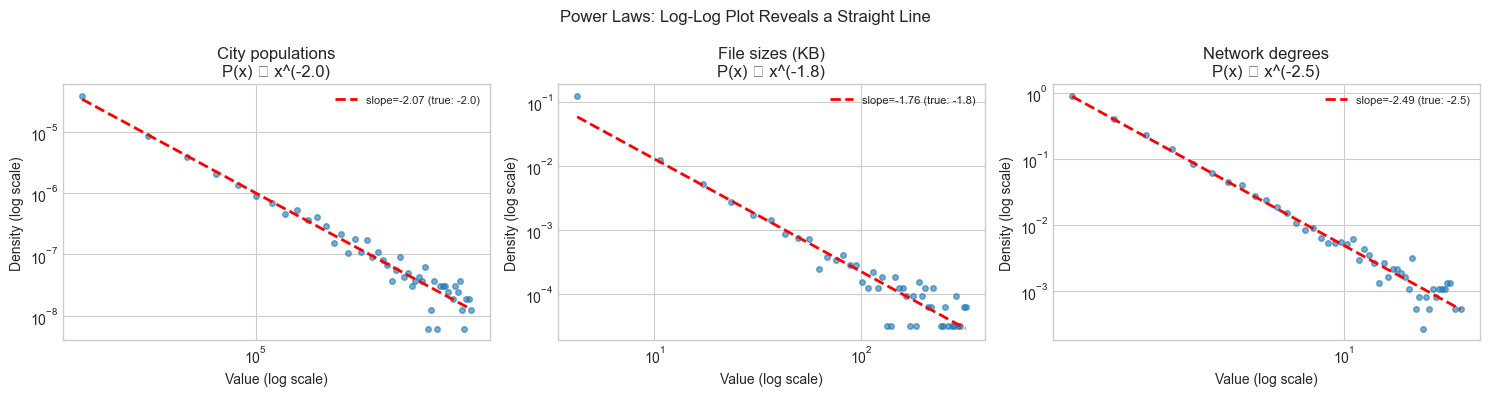

Signature of a power law: straight line on a log-log plot.
The slope is -alpha (the exponent of the distribution).
This is the mathematical pattern shared across all three domains.


In [2]:
# --- Visualization: Power laws across domains ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)

def sample_power_law(alpha, n, x_min=1.0):
    """
    Sample n values from a power-law distribution P(x) ∝ x^(-alpha).
    Uses the inverse CDF method.
    """
    u = np.random.uniform(0, 1, n)
    return x_min * (1 - u) ** (-1 / (alpha - 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

domains = [
    ('City populations', 2.0, 10000, 10000),
    ('File sizes (KB)', 1.8, 5000, 1),
    ('Network degrees', 2.5, 8000, 1),
]

for ax, (name, alpha, n, x_min) in zip(axes, domains):
    data = sample_power_law(alpha, n, x_min)
    data = data[data < np.percentile(data, 99)]  # trim extreme outliers for plot
    
    # Log-log histogram reveals straight line for power laws
    counts, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mask = counts > 0
    ax.loglog(bin_centers[mask], counts[mask], 'o', alpha=0.6, markersize=4)
    
    # Fit line on log-log scale
    log_x = np.log(bin_centers[mask])
    log_y = np.log(counts[mask])
    coeffs = np.polyfit(log_x, log_y, 1)
    ax.loglog(bin_centers[mask], np.exp(np.polyval(coeffs, log_x)),
              'r--', linewidth=2, label=f'slope={coeffs[0]:.2f} (true: {-alpha:.1f})')
    ax.set_xlabel('Value (log scale)')
    ax.set_ylabel('Density (log scale)')
    ax.set_title(f'{name}\nP(x) ∝ x^(-{alpha})')
    ax.legend(fontsize=8)

plt.suptitle('Power Laws: Log-Log Plot Reveals a Straight Line', fontsize=12)
plt.tight_layout()
plt.show()

print("Signature of a power law: straight line on a log-log plot.")
print("The slope is -alpha (the exponent of the distribution).")
print("This is the mathematical pattern shared across all three domains.")

## 4. Mathematical Formulation

**Fibonacci recurrence:** $F(n) = F(n-1) + F(n-2)$, with $F(1) = F(2) = 1$.

The closed-form solution (Binet's formula):
$$F(n) = \frac{\varphi^n - \psi^n}{\sqrt{5}}$$
where $\varphi = \frac{1+\sqrt{5}}{2}$ (golden ratio) and $\psi = \frac{1-\sqrt{5}}{2}$.

Since $|\psi| < 1$, the $\psi^n$ term vanishes as $n \to \infty$, giving $F(n) \approx \varphi^n / \sqrt{5}$. This is exponential growth with base $\varphi \approx 1.618$.

**Power law:** A quantity $X$ follows a power law with exponent $\alpha$ if:
$$P(X = x) \propto x^{-\alpha} \quad \text{for } x \geq x_{\min}$$

Taking logarithms: $\log P(x) = C - \alpha \log x$. This is linear in $\log x$ — hence the straight line on a log-log plot. The slope is $-\alpha$.

In [7]:
# --- Implementation: Binet's formula and power-law detection ---
import numpy as np

PHI = (1 + np.sqrt(5)) / 2
PSI = (1 - np.sqrt(5)) / 2

def binet(n):
    """
    Compute F(n) via Binet's closed-form formula.
    F(n) = (φⁿ - ψⁿ) / sqrt(5)
    """
    return round((PHI**n - PSI**n) / np.sqrt(5))

def fibonacci_recurrence(n):
    """Compute F(n) via recurrence."""
    if n <= 2: return 1
    a, b = 1, 1
    for _ in range(n - 2):
        a, b = b, a + b
    return b

print("Binet vs recurrence (first 20 Fibonacci numbers):")
for n in range(1, 21):
    binet_val = binet(n)
    recur_val = fibonacci_recurrence(n)
    print(f"  F({n:2d}) = {recur_val:8d}  Binet: {binet_val:8d}  Match: {binet_val == recur_val}")

def detect_power_law(data):
    """
    Estimate the power-law exponent alpha from data.
    Method: linear regression on log-log histogram.
    
    Returns:
        alpha (float): estimated exponent
        r_squared (float): goodness of fit on log-log scale
    """
    data = np.array(data)
    data = data[data > 0]
    counts, edges = np.histogram(data, bins=30, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = counts > 0
    if mask.sum() < 3:
        return None, 0
    log_x = np.log(centers[mask])
    log_y = np.log(counts[mask])
    coeffs = np.polyfit(log_x, log_y, 1)
    log_y_pred = np.polyval(coeffs, log_x)
    ss_res = np.sum((log_y - log_y_pred)**2)
    ss_tot = np.sum((log_y - log_y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return -coeffs[0], r2  # alpha = -slope

np.random.seed(1)
print("\nPower-law detection:")
for true_alpha in [1.5, 2.0, 2.5, 3.0]:
    sample = sample_power_law(true_alpha, 5000)
    est_alpha, r2 = detect_power_law(sample)
    alpha  = est_alpha.item() if est_alpha is not None else 0
    print(f"  True α={true_alpha:.1f}  Estimated α={alpha:.3f}  R²={r2:.3f}")

Binet vs recurrence (first 20 Fibonacci numbers):
  F( 1) =        1  Binet:        1  Match: True
  F( 2) =        1  Binet:        1  Match: True
  F( 3) =        2  Binet:        2  Match: True
  F( 4) =        3  Binet:        3  Match: True
  F( 5) =        5  Binet:        5  Match: True
  F( 6) =        8  Binet:        8  Match: True
  F( 7) =       13  Binet:       13  Match: True
  F( 8) =       21  Binet:       21  Match: True
  F( 9) =       34  Binet:       34  Match: True
  F(10) =       55  Binet:       55  Match: True
  F(11) =       89  Binet:       89  Match: True
  F(12) =      144  Binet:      144  Match: True
  F(13) =      233  Binet:      233  Match: True
  F(14) =      377  Binet:      377  Match: True
  F(15) =      610  Binet:      610  Match: True
  F(16) =      987  Binet:      987  Match: True
  F(17) =     1597  Binet:     1597  Match: True
  F(18) =     2584  Binet:     2584  Match: True
  F(19) =     4181  Binet:     4181  Match: True
  F(20) =     6765 

## 5. Python Implementation

*(Incorporated above — `binet`, `detect_power_law`, and `sample_power_law` constitute the chapter's implementations.)*

## 6. Experiments

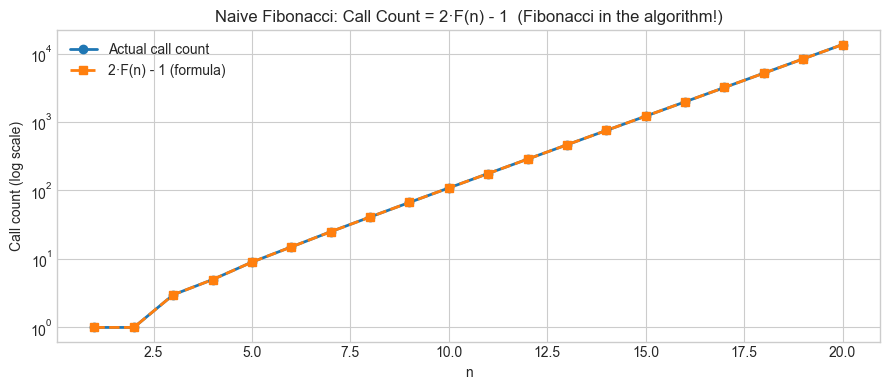

The number of function calls to compute F(n) is exactly 2·F(n) - 1.
The Fibonacci sequence appears in its own algorithm's cost.


In [8]:
# --- Experiment: Fibonacci in algorithm runtime ---
# Hypothesis: naive recursive Fibonacci has Fibonacci-number call counts
# Try changing: N_MAX

import sys
sys.setrecursionlimit(5000)

call_count = [0]

def fib_naive(n):
    """Naive recursive Fibonacci — exponential in call count."""
    call_count[0] += 1
    if n <= 2: return 1
    return fib_naive(n-1) + fib_naive(n-2)

N_MAX = 20  # <-- try: 15, 25 (warning: 30+ gets slow)

ns = list(range(1, N_MAX + 1))
calls = []
for n in ns:
    call_count[0] = 0
    fib_naive(n)
    calls.append(call_count[0])

fibs = fibonacci(N_MAX)

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9,4))
ax.semilogy(ns, calls, 'o-', label='Actual call count', linewidth=2)
ax.semilogy(ns, [2*f - 1 for f in fibs], 's--', label='2·F(n) - 1 (formula)', linewidth=2)
ax.set_xlabel('n'); ax.set_ylabel('Call count (log scale)')
ax.set_title('Naive Fibonacci: Call Count = 2·F(n) - 1  (Fibonacci in the algorithm!)')
ax.legend()
plt.tight_layout(); plt.show()

print("The number of function calls to compute F(n) is exactly 2·F(n) - 1.")
print("The Fibonacci sequence appears in its own algorithm's cost.")

## 7. Exercises

**Easy 1.** Verify Binet's formula for n=1 to 30. At what n does floating-point error cause the formula to give the wrong integer? *(Expected: find the first failing n)*

**Easy 2.** The Lucas numbers satisfy the same recurrence as Fibonacci but start at L(1)=1, L(2)=3. Compute the first 20 Lucas numbers and show that L(n)/F(n) → φ + 1/φ as n → ∞. *(Expected: converging ratio)*

**Medium 1.** Zipf's law says the k-th most common word in a large corpus has frequency ∝ 1/k (a power law with α=1). Download a text (Project Gutenberg) or generate a synthetic word frequency distribution following Zipf's law. Use `detect_power_law` to estimate α. How close is it to 1.0?

**Medium 2.** Memoization changes the call count of `fib_naive` from exponential to linear. Implement `fib_memo` using a dictionary cache and measure its call count. Plot both on the same log-scale graph. What is the call count for the memoized version as a function of n?

**Hard.** The Fibonacci sequence satisfies $F(m+n) = F(m)F(n+1) + F(m-1)F(n)$. This is the Fibonacci addition formula. Verify it computationally for all pairs (m,n) with m,n ∈ [1,50]. Then use it to design an O(log n) algorithm for computing F(n) — by analogy with fast exponentiation (repeated squaring). *(Challenge: implement and time it against the linear recurrence for n=10^6)*

## 8. Mini Project

**Self-Similarity Detector**: Given a sequence, determine whether it satisfies any linear recurrence relation of order ≤ 4, find the coefficients, and classify the asymptotic growth rate.

In [9]:
# --- Mini Project: Linear Recurrence Detector ---
import numpy as np

def fit_linear_recurrence(seq, order):
    """
    Find coefficients c1,...,c_order such that
    a[n] = c1*a[n-1] + c2*a[n-2] + ... + c_order*a[n-order].
    Uses least squares on the available data.
    """
    seq = np.array(seq, dtype=float)
    n = len(seq)
    if n <= order:
        return None, np.inf
    A = np.array([seq[i:n-order+i] for i in range(order-1, -1, -1)]).T
    b = seq[order:]
    coeffs, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    residuals = b - A @ coeffs
    rmse = np.sqrt(np.mean(residuals**2))
    return coeffs, rmse

def identify_recurrence(seq, max_order=4, tol=1e-6):
    """Find the lowest-order linear recurrence fitting the sequence."""
    for order in range(1, max_order + 1):
        coeffs, rmse = fit_linear_recurrence(seq, order)
        if coeffs is not None and rmse < tol:
            return order, coeffs, rmse
    return None, None, None

# Test sequences
test_seqs = {
    'Fibonacci':       [1,1,2,3,5,8,13,21,34,55,89,144,233,377,610],
    'Powers of 2':     [1,2,4,8,16,32,64,128,256,512,1024,2048,4096],
    'Tribonacci':      [1,1,2,4,7,13,24,44,81,149,274,504,927],  # a[n]=a[n-1]+a[n-2]+a[n-3]
    'Geometric r=3':   [1,3,9,27,81,243,729,2187,6561,19683],
    'Not recurrence':  [1,1,2,3,5,8,13,21,34,55,90],  # last term is wrong
}

print(f"{'Sequence':<20} {'Order':>6} {'RMSE':>12} {'Coefficients'}")
print("-" * 65)
for name, seq in test_seqs.items():
    order, coeffs, rmse = identify_recurrence(seq)
    if order:
        c_str = '  '.join(f'{c:.4f}' for c in coeffs)
        print(f"{name:<20} {order:>6} {rmse:>12.2e}  [{c_str}]")
    else:
        print(f"{name:<20} {'None':>6} {'—':>12}  (no recurrence of order ≤ 4 found)")

Sequence              Order         RMSE Coefficients
-----------------------------------------------------------------
Fibonacci                 2     3.91e-14  [1.0000  1.0000]
Powers of 2               1     0.00e+00  [2.0000]
Tribonacci                3     9.18e-14  [1.0000  1.0000  1.0000]
Geometric r=3             1     0.00e+00  [3.0000]
Not recurrence         None            —  (no recurrence of order ≤ 4 found)


## 9. Chapter Summary & Connections

- Repeated patterns across domains signal shared mathematical constraints, not coincidence
- Fibonacci arises wherever a quantity grows by adding its two most recent values; the golden ratio is its inevitable limit
- Power laws arise wherever multiplicative processes or preferential attachment operate; the log-log straight line is their signature
- Detecting mathematical structure computationally (recurrence fitting, log-log regression) is the algorithmic form of pattern recognition

**Forward:** The linear recurrence detector built here is a primitive version of the autoregressive models in Part IX — Statistics. The Fibonacci growth rate ($\varphi$) reappears in ch171 — Eigenvalue Computation, where $\varphi$ is the dominant eigenvalue of the Fibonacci companion matrix. Power laws connect to ch290 — Information Theory, where the entropy of a power-law distribution has special properties.

**Backward:** This chapter applies the exploration loop from ch004 *(Mathematical Curiosity and Exploration)*: we observed the Fibonacci pattern, conjectured Binet's formula, tested it, and derived the connection to the golden ratio.